In [8]:
# 감지된 이미지 관련 음성으로 들려주기
# TTS(Text To Speech) 기능을 활용하여 감지된 이미지에 대한 설명을 음성으로 출력하는 기능을 구현할 수 있습니다.
# 이를 위해 Python에서는 gTTS (Google Text-to-Speech) 라이브러리를 사용할 수 있습니다.

# 유기동물 탐지 후, 보호소 안내 메세지 음성으로 출력

# TTS 연습
from gtts import gTTS
from IPython.display import Audio               # JUPYTER NOTEBOOK에서 음성 재생을 위한 라이브러리
from playsound import playsound                 # 일반 Python 환경에서 음성 재생을 위한 라이브러리 - local 환경(vsCode)에서 실행할 때 사용

from gtts import gTTS
from IPython.display import Audio, display

def speakFunc(message):
    filename = "yolo5_test.mp3"

    tts = gTTS(text=message, lang='ko')
    tts.save(filename)

    display(Audio(filename, autoplay=True))

message = "집가고싶다"
speakFunc(message)

In [31]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from gtts import gTTS
from IPython.display import Audio
from playsound import playsound
from datetime import datetime

# 보호소 정보 안내(텍스트 + 음성 재생)
def show_shelter_info_Func(region, shelters, detected_info):
    # 지역에 따른 보호소 정보 가져오기, 없으면 기본 정보 사용
    shelter_info = shelters.get(region, shelters["기본"])

    # 감지된 동물 정보 요약
    pet_summary = f"{detected_info['count']}마리 ({', '.join(detected_info['labels'])})"

    # 보호소 정보와 감지된 동물 정보를 포함한 안내 메시지 생성
    message = (
        "\n***************************************************\n"
        f"-- 유기 동물 탐지 결과 --\n"
        f"감지된 동물: {pet_summary}\n"
        f"종류 : {detected_info['labels']}\n"
        f"{region} 지역의 보호소 정보: \n{shelter_info}"
        "\n***************************************************"
    )
    print("정보 : ", message)

    # 음성 안내
    try:
        tts = gTTS(text = f"{region}지역에 유기된 {pet_summary}가 감지되었습니다. 가까운 보호소는 {shelter_info}입니다.", lang="ko")
        tts.save("yolo5_shelter.mp3")
        display(Audio("yolo5_shelter.mp3", autoplay=True))
        
    except Exception as e:
        print("음성 안내 실패:", e)
        

def handle_stray_pet_Func(region, shelters, detected_info):
    print("유기 동물로 추정됨")
    show_shelter_info_Func(region, shelters, detected_info)

# 예시 데이터
region = "테헤란로 사거리 삼원빌딩 앞"
shelters = {
    "서울":"서울 반려동물 보호센터 : 02-1234-5678",
    "기본":"전국 유기동물 보호연합 : 1577-8888"
}
detected_info = {
    "count":3,
    "labels":["호랑이", "사자", "코끼리"]    
}

handle_stray_pet_Func(region, shelters, detected_info)


유기 동물로 추정됨
정보 :  
***************************************************
-- 유기 동물 탐지 결과 --
감지된 동물: 3마리 (호랑이, 사자, 코끼리)
종류 : ['호랑이', '사자', '코끼리']
테헤란로 사거리 삼원빌딩 앞 지역의 보호소 정보: 
전국 유기동물 보호연합 : 1577-8888
***************************************************



0: 384x640 1 cat, 1 dog, 28.1ms
Speed: 2.3ms preprocess, 28.1ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
결과 이미지가 저장되었습니다: yolo5out.jpg


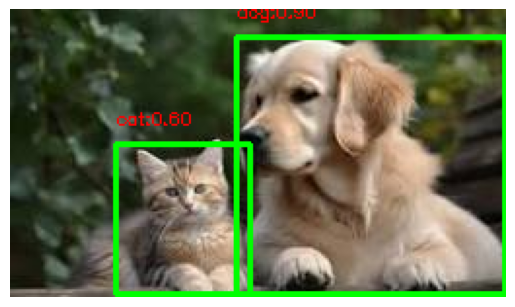


유기 동물 탐지 결과 : 
- 강아지
- 고양이
탐지 정보가 yolo5log.txt에 저장되었습니다.
정보 :  
***************************************************
-- 유기 동물 탐지 결과 --
감지된 동물: 2마리 (강아지, 고양이)
종류 : ['강아지', '고양이']
서울 지역의 보호소 정보: 
서울 반려동물 보호센터 : 02-1234-5678
***************************************************


In [41]:
# 이미지 내 객체 감지 후, 함수 호출

from datetime import datetime

# 탐지 정보 로그 저장
def save_detection_log_Func(img_path, detection_data):
    log_filename = "yolo5log.txt"
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    with open(log_filename, "a") as f:
        f.write(f"\n{now} 이미지 : {img_path}\n")
        f.write(f"탐지된 객체 수 : {len(detection_data)}\n")

        for d in detection_data:
            f.write(f" - {d['label']} : box={d['box']} confidence={d['confidence']:.2f}\n")

        f.write("-" * 40 + "\n")

    print(f"탐지 정보가 {log_filename}에 저장되었습니다.")


# 유기동물 감지 함수
def detect_pets_Func(img_path):
    pet_description = {
        "dog": "강아지",
        "cat": "고양이"
    }

    shelters = {
        "서울": "서울 반려동물 보호센터 : 02-1234-5678",
        "부산": "부산 유기동물 보호소 : 051-9876-5432",
        "기본": "전국 유기동물 보호연합 : 1577-8888"
    }

    stray_keywords = ["street", "road", "outside", "stray"]

    model = YOLO("yolo11n.pt")
    image = cv2.imread(img_path)

    if image is None:
        print(f"이미지를 불러올 수 없습니다: {img_path}")
        return

    results = model(image)

    detected_pets = []          # 감지된 동물 한글 이름
    detected_labels = []        # 감지된 동물 영어 label
    detection_data = []         # 감지된 동물 정보

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            label = model.names[int(box.cls[0])]
            confidence = box.conf[0].item()

            if label in pet_description:
                detected_labels.append(label)
                detected_pets.append(pet_description[label])

                detection_data.append({
                    "label": pet_description[label],
                    "original_label": label,
                    "confidence": confidence,
                    "box": (x1, y1, x2, y2)
                })

                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )

                cv2.putText(
                    image,
                    f"{label}:{confidence:.2f}",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.3,
                    (0, 0, 255),
                    1
                )

    # 결과 이미지 저장
    output_path = "yolo5out.jpg"
    cv2.imwrite(output_path, image)
    print(f"결과 이미지가 저장되었습니다: {output_path}")

    # 시각화
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    # 탐지 결과 출력
    if detected_pets:
        print("\n유기 동물 탐지 결과 : ")
        for pet in detected_pets:
            print(f"- {pet}")
    else:
        print("\n강아지 또는 고양이가 탐지되지 않았습니다.")

    # 감지 정보 파일로 저장
    save_detection_log_Func(img_path, detection_data)

    # 유기동물 판단
    # 조건 1: dog 또는 cat이 감지됨
    # 조건 2: 이미지 경로/파일명에 street, road, outside, stray 중 하나가 포함됨
    is_pet_detected = any(label in ["dog", "cat"] for label in detected_labels)
    is_stray_image = any(keyword in img_path.lower() for keyword in stray_keywords)

    if is_pet_detected and is_stray_image:
        detected_info = {
            "count": len(detection_data),
            "labels": sorted([d["label"] for d in detection_data])
        }

        # 유기 동물로 판단됨 --> 보호소 안내 함수 호출
        show_shelter_info_Func(
            region="서울",
            shelters=shelters,
            detected_info=detected_info
        )
    else:
        print("유기 동물 감지 X")


detect_pets_Func("/home/pnuav/HyundaiRotem_Bootcamp/python_source/yolo/street_ani.jpeg")